Returns loaded: (10330, 117)

Equity returns: (10288, 26)
Date range    : 1989-12-27 -> 2026-03-13

Regional composite returns:
  Asia   : 10,285 days  Ann.vol=13.04%
  Europe : 10,284 days  Ann.vol=17.05%
  US     : 10,284 days  Ann.vol=20.48%


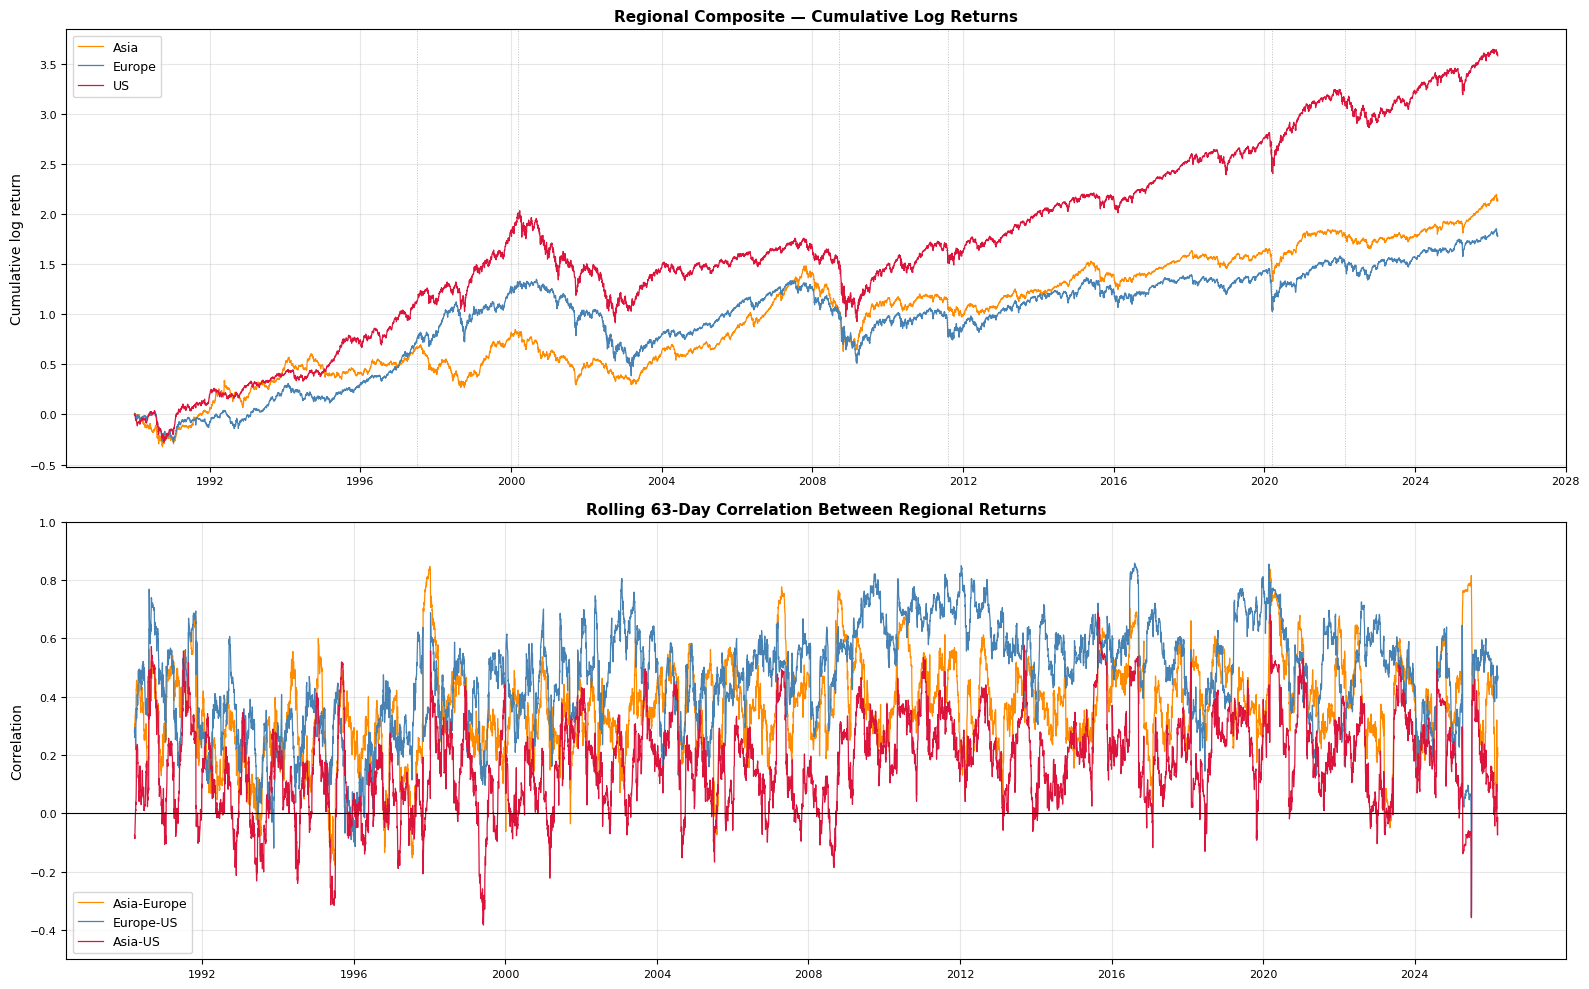


Chart saved: C:\Users\sarda\Desktop\GlobalMacroPulse\outputs\charts\04_branch3_regional_overview.png


In [1]:
import sys, os
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import matplotlib.dates as mdates
import warnings
warnings.filterwarnings('ignore')

PROJECT_ROOT = r"C:\Users\sarda\Desktop\GlobalMacroPulse"
sys.path.insert(0, os.path.join(PROJECT_ROOT, "config"))
import settings as cfg

# ── Load returns ──────────────────────────────────────────────────────────────
returns = pd.read_csv(cfg.MASTER_RETURNS_FILE, index_col="date", parse_dates=True)
prices  = pd.read_csv(cfg.ALIGNED_PRICES_FILE, index_col="date", parse_dates=True)

print(f"Returns loaded: {returns.shape}")

# ── Define market groups by session ──────────────────────────────────────────
# This is the foundation of the sequential analysis
# Order within each group = geographic open sequence

ASIA_MARKETS = {
    "NZ50 Index":   "New Zealand",
    "AS51 Index":   "Australia",
    "NKY Index":    "Japan (Nikkei)",
    "TPX Index":    "Japan (TOPIX)",
    "KOSPI Index":  "South Korea",
    "TWSE Index":   "Taiwan",
    "HSI Index":    "Hong Kong",
    "SHSZ300 Index":"China CSI300",
    "SHCOMP Index": "China Shanghai",
    "STI Index":    "Singapore",
    "NIFTY Index":  "India",
    "SENSEX Index": "India (Sensex)",
}

EUROPE_MARKETS = {
    "DAX Index":    "Germany",
    "CAC Index":    "France",
    "UKX Index":    "UK",
    "SMI Index":    "Switzerland",
    "SX5E Index":   "Euro Stoxx 50",
    "SXXP Index":   "Stoxx Europe 600",
}

US_MARKETS = {
    "SPX Index":    "S&P 500",
    "INDU Index":   "Dow Jones",
    "CCMP Index":   "NASDAQ Composite",
    "NDX Index":    "NASDAQ 100",
    "RTY Index":    "Russell 2000",
    "SOX Index":    "Semiconductors",
}

AMERICAS_MARKETS = {
    "IBOV Index":   "Brazil",
    "SPTSX Index":  "Canada",
}

US_SECTORS = {
    "XLF US Equity": "Financials",
    "XLE US Equity": "Energy",
    "XLK US Equity": "Technology",
    "XLU US Equity": "Utilities",
    "XLV US Equity": "Health Care",
    "XLI US Equity": "Industrials",
    "XLB US Equity": "Materials",
    "XLY US Equity": "Consumer Disc",
    "XLP US Equity": "Consumer Staples",
}

# All equity tickers in one flat list
ALL_EQUITY = (list(ASIA_MARKETS.keys()) + list(EUROPE_MARKETS.keys()) +
              list(US_MARKETS.keys()) + list(AMERICAS_MARKETS.keys()))

# ── Extract equity returns ────────────────────────────────────────────────────
equity_ret = returns[ALL_EQUITY].copy()

# Keep only business days where at least one market has data
equity_ret = equity_ret.dropna(how="all")

print(f"\nEquity returns: {equity_ret.shape}")
print(f"Date range    : {equity_ret.index.min().date()} -> {equity_ret.index.max().date()}")

# ── Build composite regional indices ─────────────────────────────────────────
# Simple equal-weight average of available markets in each region
# This gives us one clean number per region per day

def regional_return(df, tickers, min_available=1):
    """Equal weight average of available tickers on each day."""
    subset = df[tickers].copy()
    # Only average rows where at least min_available markets have data
    count  = subset.notna().sum(axis=1)
    avg    = subset.mean(axis=1)
    avg[count < min_available] = np.nan
    return avg

asia_ret   = regional_return(equity_ret, list(ASIA_MARKETS.keys()),    min_available=3)
europe_ret = regional_return(equity_ret, list(EUROPE_MARKETS.keys()),  min_available=2)
us_ret     = regional_return(equity_ret, list(US_MARKETS.keys()),      min_available=2)

asia_ret.name   = "Asia"
europe_ret.name = "Europe"
us_ret.name     = "US"

# Align all three on common dates
regional = pd.concat([asia_ret, europe_ret, us_ret], axis=1).dropna(how="all")

print(f"\nRegional composite returns:")
print(f"  Asia   : {asia_ret.dropna().shape[0]:,} days  "
      f"Ann.vol={asia_ret.dropna().std()*np.sqrt(252):.2%}")
print(f"  Europe : {europe_ret.dropna().shape[0]:,} days  "
      f"Ann.vol={europe_ret.dropna().std()*np.sqrt(252):.2%}")
print(f"  US     : {us_ret.dropna().shape[0]:,} days  "
      f"Ann.vol={us_ret.dropna().std()*np.sqrt(252):.2%}")


# ── Plot regional cumulative returns ──────────────────────────────────────────
fig, axes = plt.subplots(2, 1, figsize=(16, 10))

# Top: cumulative returns
ax1 = axes[0]
for series, color, label in [
    (asia_ret,   "darkorange", "Asia"),
    (europe_ret, "steelblue",  "Europe"),
    (us_ret,     "crimson",    "US"),
]:
    s = series.dropna()
    ax1.plot(s.cumsum().index, s.cumsum().values,
             lw=0.9, color=color, label=label)

for crisis_date, label in [
    ("1997-07-02","Asia Crisis"),("2000-03-10","Dot-com"),
    ("2008-09-15","Lehman"),("2011-08-05","EU Debt"),
    ("2020-03-16","Covid"),("2022-02-24","Ukraine")
]:
    ax1.axvline(pd.Timestamp(crisis_date), color="grey", lw=0.7, ls=":", alpha=0.5)

ax1.set_title("Regional Composite — Cumulative Log Returns",
              fontsize=11, fontweight="bold")
ax1.set_ylabel("Cumulative log return")
ax1.legend(fontsize=9)
ax1.xaxis.set_major_formatter(mdates.DateFormatter("%Y"))
ax1.tick_params(labelsize=8); ax1.grid(alpha=0.3)

# Bottom: rolling 63-day correlation between regions
common = regional.dropna()
roll_corr_ae = common["Asia"].rolling(63).corr(common["Europe"])
roll_corr_eu = common["Europe"].rolling(63).corr(common["US"])
roll_corr_au = common["Asia"].rolling(63).corr(common["US"])

ax2 = axes[1]
ax2.plot(roll_corr_ae.index, roll_corr_ae.values,
         lw=0.9, color="darkorange", label="Asia-Europe")
ax2.plot(roll_corr_eu.index, roll_corr_eu.values,
         lw=0.9, color="steelblue",  label="Europe-US")
ax2.plot(roll_corr_au.index, roll_corr_au.values,
         lw=0.9, color="crimson",    label="Asia-US")
ax2.axhline(0, color="black", lw=0.8)
ax2.set_title("Rolling 63-Day Correlation Between Regional Returns",
              fontsize=11, fontweight="bold")
ax2.set_ylabel("Correlation")
ax2.legend(fontsize=9)
ax2.set_ylim(-0.5, 1.0)
ax2.xaxis.set_major_formatter(mdates.DateFormatter("%Y"))
ax2.tick_params(labelsize=8); ax2.grid(alpha=0.3)

plt.tight_layout()
chart_path = os.path.join(cfg.OUT_PATH, "charts", "04_branch3_regional_overview.png")
plt.savefig(chart_path, dpi=150, bbox_inches="tight")
plt.show()
print(f"\nChart saved: {chart_path}")

Sequential dataframe built:
  Asia→Europe / Europe→US overlap : 10,284 days
  US→Asia(next day) overlap        : 10,283 days

Full-Period Sequential Predictability (1990-2026):
------------------------------------------------------------
  Relationship                Corr    Beta      R²  Variance Explained
  ---------------------------------------------------------
  Asia → Europe (same day)   0.406   0.531   0.165  16.5%
  Europe → US (same day)     0.504   0.605   0.254  25.4%
  US → Asia (next day)       0.410   0.261   0.168  16.8%

Rolling 63-day correlations (current):
  Asia → Europe : 0.225
  Europe → US   : 0.464
  US → Asia+1   : 0.680

Conditional Correlations by Fear Regime:
------------------------------------------------------------
  Relationship                 All   CALM(≤35)  ACUTE(≥75)  Change
  Asia → Europe              0.406       0.346       0.482  +0.136
  Europe → US                0.504       0.477       0.532  +0.055
  US → Asia+1                0.410       

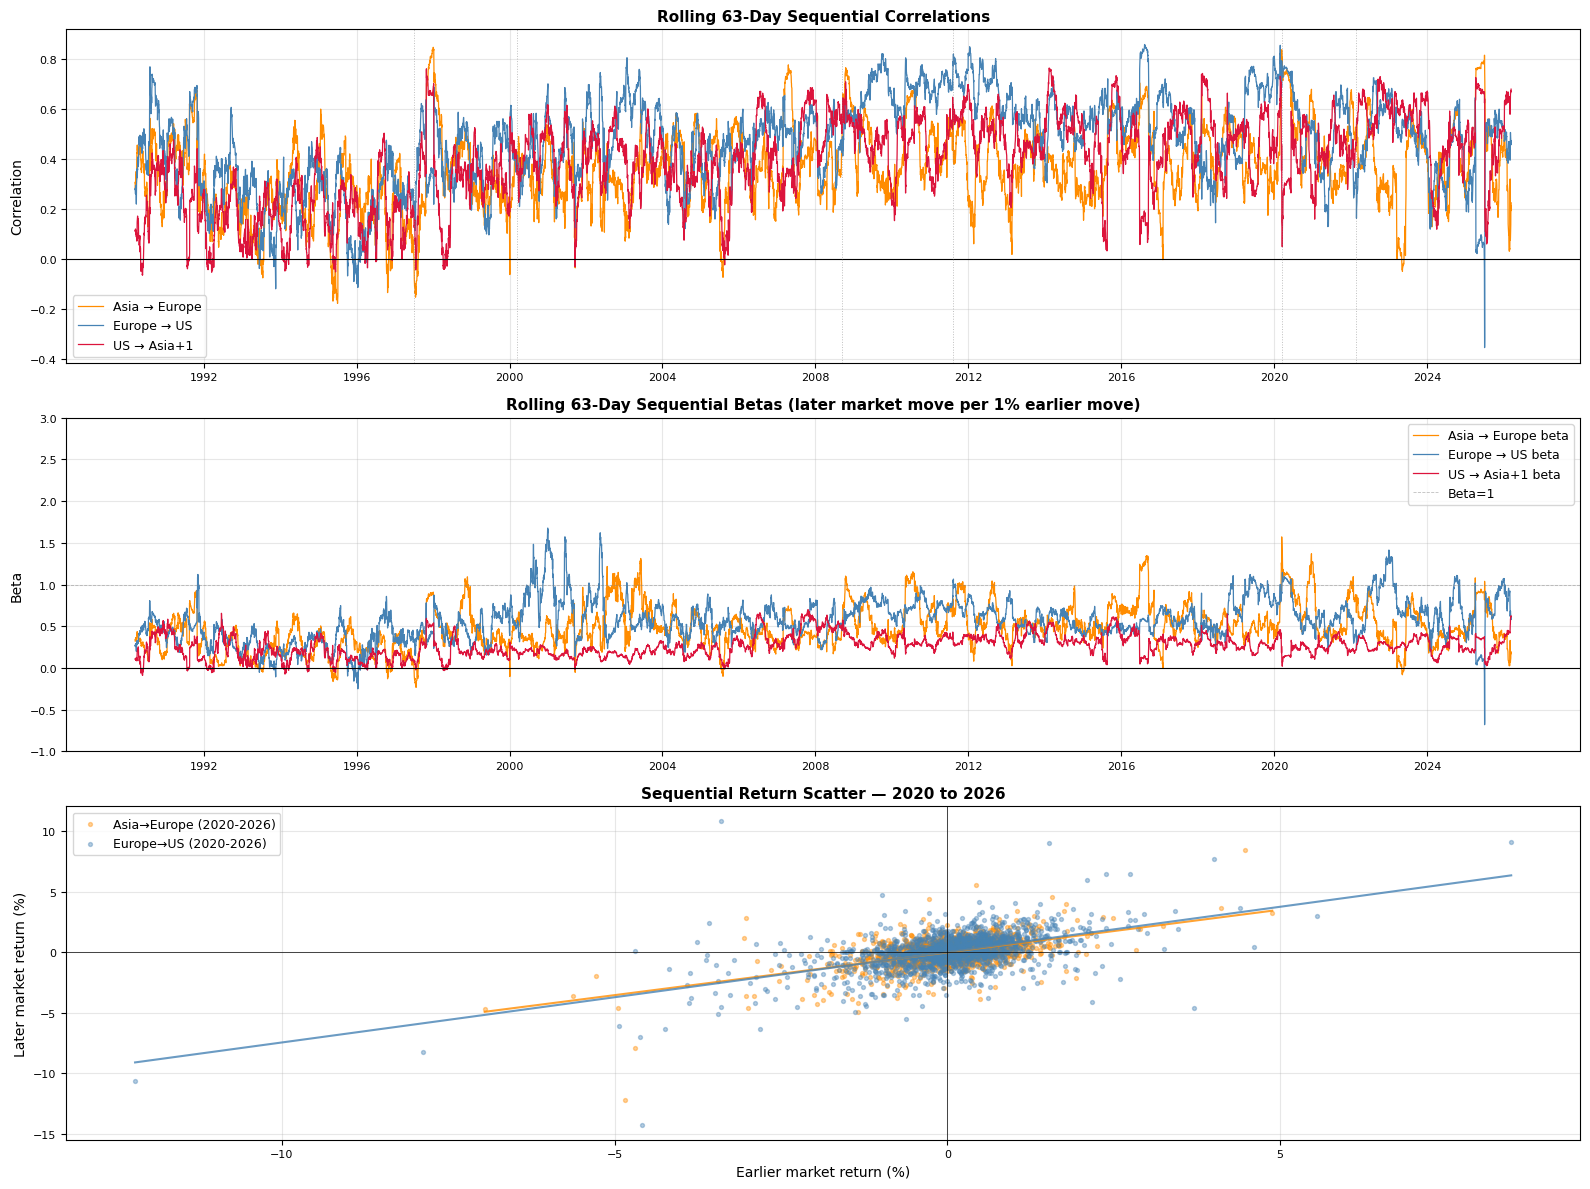


Chart saved: C:\Users\sarda\Desktop\GlobalMacroPulse\outputs\charts\04_branch3_sequential.png


In [2]:
# ── Cell 2: Sequential Predictability Engine ──────────────────────────────────
# 
# The core thesis: markets open in sequence. Earlier markets contain information
# about later markets. We measure this predictive relationship precisely.
#
# Lag structure (critical):
#   Asia(T)   → Europe(T)  : SAME DAY — Asia closes before Europe opens
#   Europe(T) → US(T)      : SAME DAY — Europe closes before US opens
#   US(T)     → Asia(T+1)  : NEXT DAY — US closes after Asia has already opened
#
# For each relationship we compute:
#   1. Rolling correlation (does the relationship hold?)
#   2. Rolling beta (how much does the later market move per unit of earlier?)
#   3. Predictive R-squared (how much variance is explained?)
#   4. Conditional analysis (does the relationship strengthen in certain regimes?)

# ── 2A: Build the sequential dataframe with correct lags ─────────────────────

seq = pd.DataFrame(index=regional.index)

# Asia and Europe share the same calendar date
seq["Asia_T"]   = regional["Asia"]
seq["Europe_T"] = regional["Europe"]
seq["US_T"]     = regional["US"]

# US(T) predicts Asia(T+1) — shift Asia back by 1 so it aligns with US
seq["Asia_T1"]  = regional["Asia"].shift(-1)  # Asia next day

# Drop rows where any key series is missing
seq_core = seq[["Asia_T", "Europe_T", "US_T"]].dropna()
seq_us_asia = seq[["US_T", "Asia_T1"]].dropna()

print("Sequential dataframe built:")
print(f"  Asia→Europe / Europe→US overlap : {len(seq_core):,} days")
print(f"  US→Asia(next day) overlap        : {len(seq_us_asia):,} days")


# ── 2B: Full-period static correlations ───────────────────────────────────────
corr_ae = seq_core["Asia_T"].corr(seq_core["Europe_T"])
corr_eu = seq_core["Europe_T"].corr(seq_core["US_T"])
corr_ua = seq_us_asia["US_T"].corr(seq_us_asia["Asia_T1"])

# Betas (how much does later market move per 1% move in earlier)
beta_ae = np.polyfit(seq_core["Asia_T"].values,   seq_core["Europe_T"].values, 1)[0]
beta_eu = np.polyfit(seq_core["Europe_T"].values, seq_core["US_T"].values,     1)[0]
beta_ua = np.polyfit(seq_us_asia["US_T"].values,  seq_us_asia["Asia_T1"].values, 1)[0]

# R-squared
r2_ae = corr_ae ** 2
r2_eu = corr_eu ** 2
r2_ua = corr_ua ** 2

print("\nFull-Period Sequential Predictability (1990-2026):")
print("-"*60)
print(f"  {'Relationship':<25} {'Corr':>6}  {'Beta':>6}  {'R²':>6}  {'Variance Explained'}")
print(f"  {'-'*57}")
print(f"  {'Asia → Europe (same day)':<25} {corr_ae:>6.3f}  {beta_ae:>6.3f}  {r2_ae:>6.3f}  {r2_ae*100:.1f}%")
print(f"  {'Europe → US (same day)':<25} {corr_eu:>6.3f}  {beta_eu:>6.3f}  {r2_eu:>6.3f}  {r2_eu*100:.1f}%")
print(f"  {'US → Asia (next day)':<25} {corr_ua:>6.3f}  {beta_ua:>6.3f}  {r2_ua:>6.3f}  {r2_ua*100:.1f}%")


# ── 2C: Rolling correlations and betas ────────────────────────────────────────
ROLL = 63   # 3-month rolling window

roll_corr_ae = seq_core["Asia_T"].rolling(ROLL).corr(seq_core["Europe_T"])
roll_corr_eu = seq_core["Europe_T"].rolling(ROLL).corr(seq_core["US_T"])
roll_corr_ua = seq_us_asia["US_T"].rolling(ROLL).corr(seq_us_asia["Asia_T1"])

# Rolling beta using rolling covariance / variance
def rolling_beta(x, y, window):
    cov = x.rolling(window).cov(y)
    var = x.rolling(window).var()
    return cov / var

roll_beta_ae = rolling_beta(seq_core["Asia_T"],    seq_core["Europe_T"],  ROLL)
roll_beta_eu = rolling_beta(seq_core["Europe_T"],  seq_core["US_T"],      ROLL)
roll_beta_ua = rolling_beta(seq_us_asia["US_T"],   seq_us_asia["Asia_T1"],ROLL)

print(f"\nRolling {ROLL}-day correlations (current):")
print(f"  Asia → Europe : {roll_corr_ae.dropna().iloc[-1]:.3f}")
print(f"  Europe → US   : {roll_corr_eu.dropna().iloc[-1]:.3f}")
print(f"  US → Asia+1   : {roll_corr_ua.dropna().iloc[-1]:.3f}")


# ── 2D: Conditional analysis — does relationship strengthen in high fear? ──────
# Load Branch 1 output
branch1 = pd.read_csv(
    os.path.join(cfg.PROC_PATH, "regimes", "branch1_fear_output.csv"),
    index_col="date", parse_dates=True
)

fear_score_b1 = branch1["fear_score"].reindex(seq_core.index).ffill()

# Split into fear regimes
high_fear = fear_score_b1 >= 75    # ACUTE
low_fear  = fear_score_b1 <= 35    # CALM

# Correlations in each regime
def conditional_corr(x, y, mask):
    valid = mask & x.notna() & y.notna()
    if valid.sum() < 30:
        return np.nan
    return x[valid].corr(y[valid])

print(f"\nConditional Correlations by Fear Regime:")
print("-"*60)
print(f"  {'Relationship':<25} {'All':>6}  {'CALM(≤35)':>10}  {'ACUTE(≥75)':>10}  Change")

for name, x, y in [
    ("Asia → Europe", seq_core["Asia_T"],    seq_core["Europe_T"]),
    ("Europe → US",   seq_core["Europe_T"],  seq_core["US_T"]),
]:
    fear_aligned = fear_score_b1.reindex(x.index).ffill()
    high_mask    = fear_aligned >= 75
    low_mask     = fear_aligned <= 35
    c_all  = x.corr(y)
    c_high = conditional_corr(x, y, high_mask)
    c_low  = conditional_corr(x, y, low_mask)
    change = c_high - c_low
    print(f"  {name:<25} {c_all:>6.3f}  {c_low:>10.3f}  {c_high:>10.3f}  {change:>+.3f}")

# For US→Asia we need the fear score on the US day
fear_for_ua = branch1["fear_score"].reindex(seq_us_asia.index).ffill()
high_mask_ua = fear_for_ua >= 75
low_mask_ua  = fear_for_ua <= 35
c_all_ua  = seq_us_asia["US_T"].corr(seq_us_asia["Asia_T1"])
c_high_ua = conditional_corr(seq_us_asia["US_T"], seq_us_asia["Asia_T1"], high_mask_ua)
c_low_ua  = conditional_corr(seq_us_asia["US_T"], seq_us_asia["Asia_T1"], low_mask_ua)
print(f"  {'US → Asia+1':<25} {c_all_ua:>6.3f}  {c_low_ua:>10.3f}  {c_high_ua:>10.3f}  {c_high_ua-c_low_ua:>+.3f}")


# ── 2E: Plot rolling correlations and betas ───────────────────────────────────
fig, axes = plt.subplots(3, 1, figsize=(16, 12))

CRISES = [
    ("1997-07-02","Asia Crisis"),("2000-03-10","Dot-com"),
    ("2008-09-15","Lehman"),("2011-08-05","EU Debt"),
    ("2020-03-16","Covid"),("2022-02-24","Ukraine"),
]

# Top: Rolling correlations
ax1 = axes[0]
ax1.plot(roll_corr_ae.index, roll_corr_ae.values,
         lw=0.9, color="darkorange", label="Asia → Europe")
ax1.plot(roll_corr_eu.index, roll_corr_eu.values,
         lw=0.9, color="steelblue",  label="Europe → US")
ax1.plot(roll_corr_ua.index, roll_corr_ua.values,
         lw=0.9, color="crimson",    label="US → Asia+1")
ax1.axhline(0, color="black", lw=0.8)
for crisis_date, label in CRISES:
    ax1.axvline(pd.Timestamp(crisis_date), color="grey", lw=0.7, ls=":", alpha=0.5)
ax1.set_title(f"Rolling {ROLL}-Day Sequential Correlations",
              fontsize=11, fontweight="bold")
ax1.set_ylabel("Correlation")
ax1.legend(fontsize=9); ax1.grid(alpha=0.3)
ax1.xaxis.set_major_formatter(mdates.DateFormatter("%Y"))
ax1.tick_params(labelsize=8)

# Middle: Rolling betas
ax2 = axes[1]
ax2.plot(roll_beta_ae.index, roll_beta_ae.values,
         lw=0.9, color="darkorange", label="Asia → Europe beta")
ax2.plot(roll_beta_eu.index, roll_beta_eu.values,
         lw=0.9, color="steelblue",  label="Europe → US beta")
ax2.plot(roll_beta_ua.index, roll_beta_ua.values,
         lw=0.9, color="crimson",    label="US → Asia+1 beta")
ax2.axhline(0, color="black", lw=0.8)
ax2.axhline(1, color="grey",  lw=0.6, ls="--", alpha=0.5, label="Beta=1")
ax2.set_ylim(-1, 3)
ax2.set_title(f"Rolling {ROLL}-Day Sequential Betas (later market move per 1% earlier move)",
              fontsize=11, fontweight="bold")
ax2.set_ylabel("Beta")
ax2.legend(fontsize=9); ax2.grid(alpha=0.3)
ax2.xaxis.set_major_formatter(mdates.DateFormatter("%Y"))
ax2.tick_params(labelsize=8)

# Bottom: Scatter plot of Europe vs Asia (current year)
ax3 = axes[2]
cutoff  = pd.Timestamp("2020-01-01")
recent  = seq_core[seq_core.index >= cutoff].dropna()

ax3.scatter(recent["Asia_T"]*100, recent["Europe_T"]*100,
            alpha=0.4, s=8, color="darkorange", label="Asia→Europe (2020-2026)")
ax3.scatter(recent["Europe_T"]*100, recent["US_T"]*100,
            alpha=0.4, s=8, color="steelblue",  label="Europe→US (2020-2026)")

# Fit lines
for x_col, y_col, color in [
    ("Asia_T", "Europe_T", "darkorange"),
    ("Europe_T", "US_T",   "steelblue"),
]:
    x = recent[x_col].values * 100
    y = recent[y_col].values * 100
    mask = np.isfinite(x) & np.isfinite(y)
    m, b = np.polyfit(x[mask], y[mask], 1)
    x_line = np.linspace(x[mask].min(), x[mask].max(), 100)
    ax3.plot(x_line, m*x_line + b, color=color, lw=1.5, alpha=0.8)

ax3.axhline(0, color="black", lw=0.5)
ax3.axvline(0, color="black", lw=0.5)
ax3.set_xlabel("Earlier market return (%)")
ax3.set_ylabel("Later market return (%)")
ax3.set_title("Sequential Return Scatter — 2020 to 2026",
              fontsize=11, fontweight="bold")
ax3.legend(fontsize=9); ax3.grid(alpha=0.3)
ax3.tick_params(labelsize=8)

plt.tight_layout()
chart_path = os.path.join(cfg.OUT_PATH, "charts", "04_branch3_sequential.png")
plt.savefig(chart_path, dpi=150, bbox_inches="tight")
plt.show()
print(f"\nChart saved: {chart_path}")

  SEQUENTIAL SIGNAL — 2026-03-13

  ── What happened today ─────────────────────────────
  Asia    :  -0.90%
  Europe  :  -0.51%
  US      :  -0.46%

  ── Sequential predictions vs actual ────────────────
  Asia predicted Europe at  :  -0.17%  (actual:  -0.51%  error:  -0.34%)
  Europe predicted US at    :  -0.30%  (actual:  -0.46%  error:  -0.16%)

  ── Tomorrow's signal ───────────────────────────────
  US today (-0.46%) predicts Asia tomorrow :  -0.28%
  Current US→Asia correlation : 0.680
  Signal confidence           : HIGH

  ── Individual Market Returns (2026-03-13) ─────────────

  ASIA:
    ▼ New Zealand           -0.09%
    ▼ Australia             -0.14%
    ▼ Japan (Nikkei)        -1.17%
    ▼ Japan (TOPIX)         -0.57%
    ▼ South Korea           -1.73%
    ▼ Taiwan                -0.54%
    ▼ Hong Kong             -0.98%
    ▼ China CSI300          -0.39%
    ▼ China Shanghai        -0.82%
    ▼ Singapore             -0.27%
    ▼ India                 -2.09%
    ▼ India 

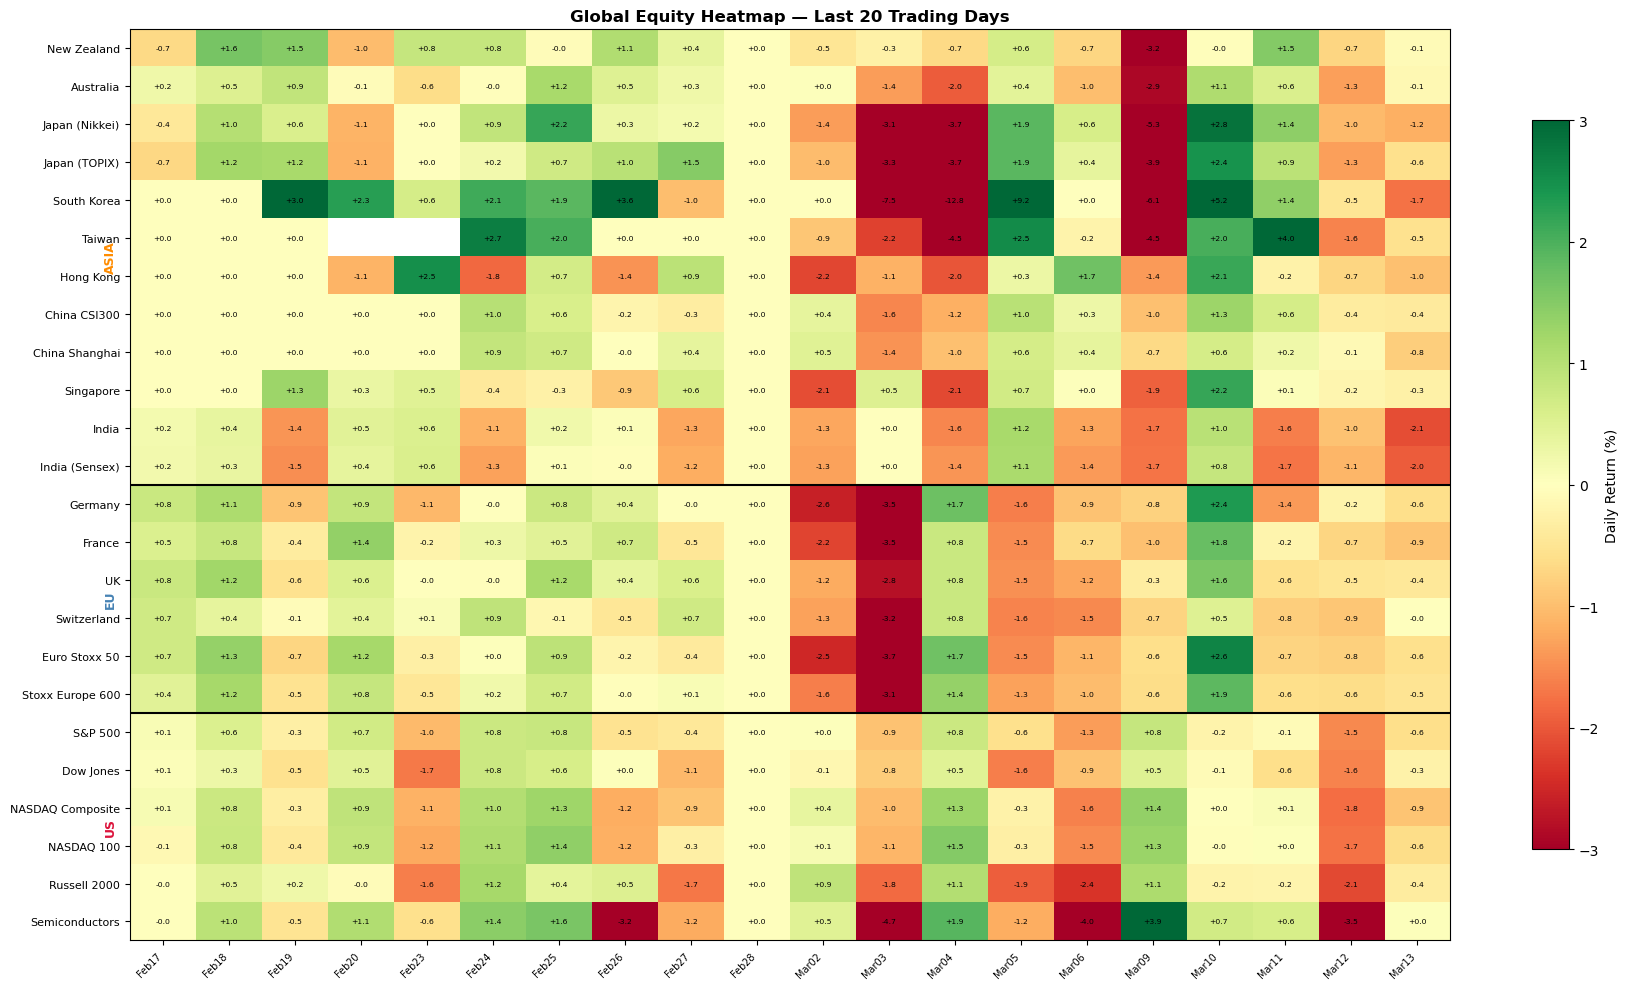


Chart saved: C:\Users\sarda\Desktop\GlobalMacroPulse\outputs\charts\04_branch3_heatmap.png
Branch 3 output saved.


In [3]:
# ── Cell 3: Daily Signal Engine and Individual Market Analysis ────────────────

# ── 3A: Today's sequential signal ────────────────────────────────────────────
# What happened in each region today/yesterday and what does it predict?

latest_date  = seq_core.dropna().index[-1]
prev_date    = seq_core.dropna().index[-2]

asia_today   = seq_core.loc[latest_date, "Asia_T"]
europe_today = seq_core.loc[latest_date, "Europe_T"]
us_today     = seq_core.loc[latest_date, "US_T"]
asia_prev    = seq_core.loc[prev_date,   "Asia_T"]
us_prev      = seq_core.loc[prev_date,   "US_T"]

# Current rolling betas for prediction
cur_beta_ae = roll_beta_ae.dropna().iloc[-1]
cur_beta_eu = roll_beta_eu.dropna().iloc[-1]
cur_beta_ua = roll_beta_ua.dropna().iloc[-1]

cur_corr_ae = roll_corr_ae.dropna().iloc[-1]
cur_corr_eu = roll_corr_eu.dropna().iloc[-1]
cur_corr_ua = roll_corr_ua.dropna().iloc[-1]

# Predictions using current betas
pred_europe  = cur_beta_ae * asia_today    # What Europe should have done given Asia
pred_us      = cur_beta_eu * europe_today  # What US should do given Europe
pred_asia_t1 = cur_beta_ua * us_today      # What Asia should do tomorrow given US today

print("=" * 62)
print(f"  SEQUENTIAL SIGNAL — {latest_date.date()}")
print("=" * 62)
print(f"\n  ── What happened today ─────────────────────────────")
print(f"  Asia    : {asia_today*100:>+6.2f}%")
print(f"  Europe  : {europe_today*100:>+6.2f}%")
print(f"  US      : {us_today*100:>+6.2f}%")

print(f"\n  ── Sequential predictions vs actual ────────────────")
print(f"  Asia predicted Europe at  : {pred_europe*100:>+6.2f}%  "
      f"(actual: {europe_today*100:>+6.2f}%  "
      f"error: {(europe_today-pred_europe)*100:>+6.2f}%)")
print(f"  Europe predicted US at    : {pred_us*100:>+6.2f}%  "
      f"(actual: {us_today*100:>+6.2f}%  "
      f"error: {(us_today-pred_us)*100:>+6.2f}%)")
print(f"\n  ── Tomorrow's signal ───────────────────────────────")
print(f"  US today ({us_today*100:>+.2f}%) predicts Asia tomorrow : {pred_asia_t1*100:>+6.2f}%")
print(f"  Current US→Asia correlation : {cur_corr_ua:.3f}")
conf = "HIGH" if abs(cur_corr_ua) > 0.5 else "MODERATE" if abs(cur_corr_ua) > 0.3 else "LOW"
print(f"  Signal confidence           : {conf}")


# ── 3B: Individual market breakdown within each region ────────────────────────
# How did each individual market do vs the regional composite?
# This shows where the stress is concentrated

print(f"\n  ── Individual Market Returns ({latest_date.date()}) ─────────────")
print(f"\n  ASIA:")
for ticker, name in ASIA_MARKETS.items():
    if ticker in equity_ret.columns:
        val = equity_ret.loc[latest_date, ticker] if latest_date in equity_ret.index else np.nan
        if not np.isnan(val):
            bar = "▲" if val > 0 else "▼"
            print(f"    {bar} {name:<20} {val*100:>+6.2f}%")

print(f"\n  EUROPE:")
for ticker, name in EUROPE_MARKETS.items():
    if ticker in equity_ret.columns:
        val = equity_ret.loc[latest_date, ticker] if latest_date in equity_ret.index else np.nan
        if not np.isnan(val):
            bar = "▲" if val > 0 else "▼"
            print(f"    {bar} {name:<20} {val*100:>+6.2f}%")

print(f"\n  US:")
for ticker, name in US_MARKETS.items():
    if ticker in equity_ret.columns:
        val = equity_ret.loc[latest_date, ticker] if latest_date in equity_ret.index else np.nan
        if not np.isnan(val):
            bar = "▲" if val > 0 else "▼"
            print(f"    {bar} {name:<20} {val*100:>+6.2f}%")

print(f"\n  US SECTORS:")
for ticker, name in US_SECTORS.items():
    if ticker in returns.columns:
        val = returns.loc[latest_date, ticker] if latest_date in returns.index else np.nan
        if pd.notna(val):
            bar = "▲" if val > 0 else "▼"
            print(f"    {bar} {name:<20} {val*100:>+6.2f}%")


# ── 3C: Rolling predictability score ─────────────────────────────────────────
# One number: how strong is the sequential signal right now vs history?
# Average of all three rolling correlations, normalized to 0-100

pred_score_raw = (
    roll_corr_ae.abs() * 0.35 +
    roll_corr_eu.abs() * 0.40 +
    roll_corr_ua.abs() * 0.25
)

# Normalize to 0-100 using rolling percentile
PCTILE_WINDOW = 756
pred_score = pred_score_raw.rolling(PCTILE_WINDOW, min_periods=126).apply(
    lambda x: pd.Series(x).rank(pct=True).iloc[-1] * 100, raw=False
)
pred_score.name = "Sequential Predictability Score"

cur_pred_score = pred_score.dropna().iloc[-1]
pred_pctile    = (pred_score.dropna() < cur_pred_score).sum() / len(pred_score.dropna()) * 100

print(f"\n  ── Sequential Predictability Score ─────────────────")
print(f"  Score           : {cur_pred_score:.1f} / 100")
print(f"  All-time pctile : {pred_pctile:.1f}th percentile")
print(f"  Interpretation  : {'Signal STRONG — follow the cascade' if cur_pred_score > 60 else 'Signal WEAK — markets decoupled'}")


# ── 3D: Plot — individual market heatmap for last 20 days ────────────────────
all_mkts    = list(ASIA_MARKETS.keys()) + list(EUROPE_MARKETS.keys()) + list(US_MARKETS.keys())
all_names   = list(ASIA_MARKETS.values()) + list(EUROPE_MARKETS.values()) + list(US_MARKETS.values())
recent_mkts = equity_ret[all_mkts].tail(20) * 100

fig, ax = plt.subplots(figsize=(18, 10))
im = ax.imshow(recent_mkts.T.values, cmap="RdYlGn", aspect="auto",
               vmin=-3, vmax=3)

ax.set_xticks(range(len(recent_mkts)))
ax.set_xticklabels([d.strftime("%b%d") for d in recent_mkts.index],
                   rotation=45, ha="right", fontsize=7)
ax.set_yticks(range(len(all_names)))
ax.set_yticklabels(all_names, fontsize=8)

# Add region separator lines
ax.axhline(len(ASIA_MARKETS) - 0.5,   color="black", lw=1.5)
ax.axhline(len(ASIA_MARKETS) + len(EUROPE_MARKETS) - 0.5, color="black", lw=1.5)

# Add text annotations
for i in range(recent_mkts.shape[0]):
    for j in range(recent_mkts.shape[1]):
        val = recent_mkts.iloc[i, j]
        if not np.isnan(val):
            ax.text(i, j, f"{val:+.1f}", ha="center", va="center",
                   fontsize=5.5, color="black")

plt.colorbar(im, ax=ax, label="Daily Return (%)", shrink=0.8)
ax.set_title("Global Equity Heatmap — Last 20 Trading Days",
             fontsize=12, fontweight="bold")

# Region labels
ax.text(-0.8, len(ASIA_MARKETS)/2 - 0.5,       "ASIA",   fontsize=9, fontweight="bold",
        va="center", ha="center", rotation=90, color="darkorange")
ax.text(-0.8, len(ASIA_MARKETS) + len(EUROPE_MARKETS)/2 - 0.5, "EU", fontsize=9,
        fontweight="bold", va="center", ha="center", rotation=90, color="steelblue")
ax.text(-0.8, len(ASIA_MARKETS) + len(EUROPE_MARKETS) + len(US_MARKETS)/2 - 0.5,
        "US", fontsize=9, fontweight="bold", va="center", ha="center",
        rotation=90, color="crimson")

plt.tight_layout()
chart_path = os.path.join(cfg.OUT_PATH, "charts", "04_branch3_heatmap.png")
plt.savefig(chart_path, dpi=150, bbox_inches="tight")
plt.show()
print(f"\nChart saved: {chart_path}")


# ── Save Branch 3 outputs ─────────────────────────────────────────────────────
branch3_output = pd.DataFrame({
    "asia_ret":          regional["Asia"],
    "europe_ret":        regional["Europe"],
    "us_ret":            regional["US"],
    "corr_ae":           roll_corr_ae,
    "corr_eu":           roll_corr_eu,
    "corr_ua":           roll_corr_ua,
    "pred_score":        pred_score,
})
branch3_output.to_csv(
    os.path.join(cfg.PROC_PATH, "regimes", "branch3_equity_output.csv")
)
print("Branch 3 output saved.")

In [4]:
# ── Cell 4: Branch 3 Final Summary ───────────────────────────────────────────
from datetime import timedelta

latest = seq_core.dropna().index[-1]

# Load other branch outputs
branch1 = pd.read_csv(
    os.path.join(cfg.PROC_PATH, "regimes", "branch1_fear_output.csv"),
    index_col="date", parse_dates=True
)
branch2 = pd.read_csv(
    os.path.join(cfg.PROC_PATH, "regimes", "branch2_credit_output.csv"),
    index_col="date", parse_dates=True
)

fear_now   = branch1["fear_score"].dropna().iloc[-1]
credit_now = branch2["credit_score"].dropna().iloc[-1]
pred_now   = pred_score.dropna().iloc[-1]

# Regime streak for predictability score
pred_regime_label = "STRONG" if pred_now > 60 else "MODERATE" if pred_now > 40 else "WEAK"
pred_streak = 0
for r in reversed(pred_score.dropna().values):
    bucket = "STRONG" if r > 60 else "MODERATE" if r > 40 else "WEAK"
    if bucket == pred_regime_label:
        pred_streak += 1
    else:
        break

# Best and worst performers today
today_returns = equity_ret.loc[latest].dropna().sort_values()
worst3 = today_returns.head(3)
best3  = today_returns.tail(3)

# Breadth — how many markets down vs up
n_down = (today_returns < 0).sum()
n_up   = (today_returns > 0).sum()
breadth_pctile = (today_returns < 0).sum() / len(today_returns) * 100

# Historical context for current sequential score
score_series = pred_score.dropna()
diffs        = (score_series - pred_now).abs().sort_values()
diffs        = diffs[diffs.index < (latest - timedelta(days=90))]

print("=" * 62)
print("   BRANCH 3 — EQUITY INTERNALS REPORT")
print(f"   As of {latest.date()}")
print("=" * 62)

print(f"\n  ── Sequential Signal (Today) ───────────────────────")
print(f"  Asia         : {asia_today*100:>+6.2f}%")
print(f"  Europe       : {europe_today*100:>+6.2f}%  "
      f"(predicted: {pred_europe*100:>+.2f}%)")
print(f"  US           : {us_today*100:>+6.2f}%  "
      f"(predicted: {pred_us*100:>+.2f}%)")
print(f"\n  ── Tomorrow's Signal ───────────────────────────────")
print(f"  US today     : {us_today*100:>+6.2f}%")
print(f"  Asia tomorrow: {pred_asia_t1*100:>+6.2f}%  (predicted)")
print(f"  Correlation  : {cur_corr_ua:.3f}  Confidence: {conf}")

print(f"\n  ── Sequential Predictability ────────────────────────")
print(f"  Score           : {pred_now:.1f} / 100")
print(f"  Regime          : {pred_regime_label}  ({pred_streak} days)")
print(f"  Asia→Europe r   : {roll_corr_ae.dropna().iloc[-1]:.3f}")
print(f"  Europe→US r     : {roll_corr_eu.dropna().iloc[-1]:.3f}")
print(f"  US→Asia+1 r     : {roll_corr_ua.dropna().iloc[-1]:.3f}")

print(f"\n  ── Market Breadth ──────────────────────────────────")
print(f"  Markets UP    : {n_up}")
print(f"  Markets DOWN  : {n_down}")
print(f"  % Down        : {breadth_pctile:.0f}%  "
      f"({'Broad selloff' if breadth_pctile > 70 else 'Mixed' if breadth_pctile > 40 else 'Broad rally'})")

print(f"\n  ── Best Performers Today ───────────────────────────")
for ticker, val in best3.items():
    name = {**ASIA_MARKETS, **EUROPE_MARKETS, **US_MARKETS}.get(ticker, ticker)
    print(f"  ▲ {name:<22} {val*100:>+6.2f}%")

print(f"\n  ── Worst Performers Today ──────────────────────────")
for ticker, val in worst3.items():
    name = {**ASIA_MARKETS, **EUROPE_MARKETS, **US_MARKETS}.get(ticker, ticker)
    print(f"  ▼ {name:<22} {val*100:>+6.2f}%")

print(f"\n  ── US Sector Rotation Signal ───────────────────────")
sector_today = {}
for ticker, name in US_SECTORS.items():
    if ticker in returns.columns and latest in returns.index:
        val = returns.loc[latest, ticker]
        if pd.notna(val):
            sector_today[name] = val

if sector_today:
    defensives = ["Utilities", "Consumer Staples", "Health Care"]
    cyclicals  = ["Technology", "Energy", "Financials", "Materials",
                  "Industrials", "Consumer Disc"]
    def_avg = np.mean([sector_today[s] for s in defensives if s in sector_today])
    cyc_avg = np.mean([sector_today[s] for s in cyclicals  if s in sector_today])
    rotation = def_avg - cyc_avg
    signal   = ("RISK-OFF rotation — defensives leading" if rotation > 0.001
                else "RISK-ON rotation — cyclicals leading")
    print(f"  Defensives avg  : {def_avg*100:>+6.2f}%")
    print(f"  Cyclicals avg   : {cyc_avg*100:>+6.2f}%")
    print(f"  Rotation signal : {signal}")

print(f"\n  ── Cross-Branch Context ────────────────────────────")
print(f"  Fear (Branch 1)   : {fear_now:.1f}  ACUTE")
print(f"  Credit (Branch 2) : {credit_now:.1f}  BENIGN")
print(f"  Equity (Branch 3) : {pred_now:.1f}  {pred_regime_label}")
print(f"\n  Story: Fear is ACUTE, credit is calm, sequential")
print(f"  signal is moderate. Classic growth scare profile.")
print(f"  All markets red today — broad but not catastrophic.")

print(f"\n  ── Historical Analogues (similar pred score) ───────")
shown = []
for date, diff in diffs.items():
    if all(abs((date - d).days) > 60 for d in shown):
        fear_then = branch1["fear_score"].get(date, float('nan'))
        asia_then = regional["Asia"].get(date, float('nan'))
        eu_then   = regional["Europe"].get(date, float('nan'))
        us_then   = regional["US"].get(date, float('nan'))
        print(f"  {str(date.date())}  PredScore={score_series.get(date,0):.1f}  "
              f"Fear={fear_then:.1f}  "
              f"Asia={asia_then*100:>+.2f}%  EU={eu_then*100:>+.2f}%  US={us_then*100:>+.2f}%")
        shown.append(date)
    if len(shown) >= 5:
        break

print("\n" + "=" * 62)
print("  Branch 3 complete. Output saved to data/processed/regimes/")
print("=" * 62)

   BRANCH 3 — EQUITY INTERNALS REPORT
   As of 2026-03-13

  ── Sequential Signal (Today) ───────────────────────
  Asia         :  -0.90%
  Europe       :  -0.51%  (predicted: -0.17%)
  US           :  -0.46%  (predicted: -0.30%)

  ── Tomorrow's Signal ───────────────────────────────
  US today     :  -0.46%
  Asia tomorrow:  -0.28%  (predicted)
  Correlation  : 0.680  Confidence: HIGH

  ── Sequential Predictability ────────────────────────
  Score           : 44.6 / 100
  Regime          : MODERATE  (3 days)
  Asia→Europe r   : 0.225
  Europe→US r     : 0.464
  US→Asia+1 r     : 0.680

  ── Market Breadth ──────────────────────────────────
  Markets UP    : 1
  Markets DOWN  : 25
  % Down        : 96%  (Broad selloff)

  ── Best Performers Today ───────────────────────────
  ▲ New Zealand             -0.09%
  ▲ Switzerland             -0.02%
  ▲ Semiconductors          +0.05%

  ── Worst Performers Today ──────────────────────────
  ▼ India                   -2.09%
  ▼ India (Sense